# Power performance of a WEC system
This notebook demonstrates solving the motion of a hydrodynamic system, calculating power, and evaluating the gradient of the system power with respect to PTO damping.

1. Define or ingest hydrodynamic coefficients
2. Define numerical simulation parameters and wave conditions
3. Define body mass properties, initial conditions, and PTO damping
4. Solve the system and calculate power
5. Gradient of power with respect to PTO damping

In [54]:
# First import all necessary julia packages:
using Unitful
using DimensionfulAngles: radᵃ as rad, θ₀, 𝐀
using LinearAlgebra
import BenchmarkTools as BT
using Plots
import Random
import Statistics as Stats
import Zygote
import ReverseDiff as RD
import ForwardDiff as FD
import Optimization as OPT
import OptimizationOptimisers as OPTOPT
import OptimizationPolyalgorithms as OPA
import WaveSpectra

include("..\\src\\Hydrodynamics.jl")

Main.Hydrodynamics

In [55]:
# Hydrodynamics
hydro = Hydrodynamics.Bemio.read_capytaine("data//rm3.nc")

addedMassUnits = 1.0 .* [repeat([u"kg"], 3, 3) repeat([0u"kg*m"/rad], 3, 3); repeat([0u"kg*m"], 3, 3) repeat([0u"kg*m^2"/rad], 3, 3)]
addedMassCoeff = hydro.am[1:6, 1:6, :] .* addedMassUnits # Dimensions: influenced_dof radiating_dof omega

# Don't define force units with Newtons -- it will end up causing conflicts in the out-of-place ODE solve (OOP is required for Zygote)
radDampingUnits = 1.0 * [repeat([u"kg*m/s^2 / (m/s)"], 3, 3) repeat([u"kg*m/s^2 / (1/s)"/rad], 3, 3); repeat([u"kg*m/s^2 * m / (m/s)"], 3, 3) repeat([u"kg*m/s^2 * m / (1/s)"/rad], 3, 3)]
radDampingCoeff = hydro.rd[1:6, 1:6, :] .* radDampingUnits # Dimensions: influenced_dof radiating_dof omega

khsUnits = 1.0 .* [repeat([u"kg*m/s^2 / m"], 3, 3) repeat([u"kg*m/s^2"/rad], 3, 3); repeat([u"kg*m/s^2 * m / m"], 3, 3) repeat([u"kg*m/s^2 * m"/rad], 3, 3)]
khsCoeff = hydro.khs[1:6, 1:6] .* khsUnits # Dimensions: influenced_dof radiating_dof

exUnits = [repeat([u"kg*m/s^2 / m"], 3, 1); repeat([u"kg*m/s^2 * m / m"], 3, 1)]
exCoeff = hydro.ex[1:6, :, :, :] .* exUnits # Dimensions: influenced_dof wave_dir omega complex


6×1×260×2 Array{Quantity{Float64}, 4}:
[:, :, 1, 1] =
  2.0311041737386404e-8 kg s^-2
  5.822897719554021e-11 kg s^-2
  2.8001482923547793e6 kg s^-2
 -1.2110490388295148e-10 kg m s^-2
  2.1285016593708406e-7 kg m s^-2
  1.295225884265374e-11 kg m s^-2

[:, :, 2, 1] =
 5.179072573469057e-6 kg s^-2
 5.7838178690872155e-11 kg s^-2
 2.797665062134365e6 kg s^-2
 1.2583996067405678e-9 kg m s^-2
 5.425501727529536e-5 kg m s^-2
 1.1404373261448674e-11 kg m s^-2

[:, :, 3, 1] =
  0.00013186801719200503 kg s^-2
 -2.5693225325085223e-11 kg s^-2
  2.793499390076672e6 kg s^-2
 -9.708855941426009e-10 kg m s^-2
  0.0013805005377349744 kg m s^-2
  1.2105648684271764e-11 kg m s^-2

;;; … 

[:, :, 258, 1] =
 2961.423416463907 kg s^-2
   -0.00034335423481479665 kg s^-2
  609.279939604098 kg s^-2
    0.00850901668206916 kg m s^-2
 -116.27806247850049 kg m s^-2
   -1.7564273358775147e-9 kg m s^-2

[:, :, 259, 1] =
 -2730.4245875278366 kg s^-2
    -0.00032349539299048047 kg s^-2
   568.9036671246315 kg s^-2

### Wave conditions and numerical set-up
Define relevant wave using WaveSpectra representations (including height, period, spectra, frequency dimension, etc) and time marching parameters (start, ramp, end times; time step)

In [56]:
# Wave conditions
height = 1.0u"m"
amplitude = height/2
period = 6.0u"s"
peakOmega = 2*pi*rad/period
peakFrequency = 1/period

# Numerical set-up
# dt = 10u"ms" # results in type Rational when combined used in the `collect` call
dt = 1.0e-1u"s"
t0 = 0.0u"s"
tf = period * 10
ts = collect(t0:dt:tf)
nt = length(ts)
ramp_time = 6.0*1u"s"
i_ramp = Int64(ramp_time / dt + 1)

# Wave set-up
omegaVector = hydro.w*rad*u"1/s"
dOmega = omegaVector[2] - omegaVector[1]
peakOmegaIndex = argmin(abs.(omegaVector.-peakOmega))

frequencyVector = omegaVector / (2*pi*rad)
dFrequency = frequencyVector[2] - frequencyVector[1]
phase = rand(Random.Xoshiro(0), Float64, size(frequencyVector)) * 2 * pi * rad

spectrum = Hydrodynamics.piersonMoskowitzSpectrum(height, peakFrequency, frequencyVector)
elevation = sum(sqrt.(2*spectrum*dFrequency) .* cos.(omegaVector.*ts' .+ phase), dims=1)

1×601 Matrix{Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}:
 0.265312 m  0.281176 m  0.296391 m  …  0.141376 m  0.186339 m  0.228303 m

### Define body properties
The required body properties include center of gravity and center of buoyancy, mass, moments and products of inertia, displaced volume, and any initial displacements of the bodies.

Adam TODO - add gravity and buoyancy

PTO damping is lumped with radiation damping when the system of equations is solved, but it is defined as a separate input parameter so that it is a distinct input to power production and can be optimized accordingly.

In [57]:
# Body properties
cg = [0., 0., -3.5]u"m"
m = 725833u"kg"
Ixx = [20907301, 21306090.66, 37085481.11]u"kg*m^2"/rad
Ixy = [1e6, 1e6, 1e5]u"kg*m^2"/rad
I = diagm(Ixx)
I[1, 2:3] = I[2:3, 1] = Ixy[1:2]
I[2, 3] = I[3, 2] = Ixy[3]
M = [diagm(repeat([m], 3)) repeat([0u"kg*m"/rad], 3, 3); repeat([0u"kg*m"], 3, 3) I]

# Coefficients for the form: ẍ + c * ẋ + k * x = 0
dofStrings = ["Surge", "Sway", "Heave", "Roll", "Pitch", "Yaw"]
dof = 1:2:5
positionUnits = [u"m", u"m", u"m", rad, rad, rad]
mass = (M[dof,dof] .+ addedMassCoeff[dof, dof, peakOmegaIndex])
invMassUnits = 1 ./ Unitful.unit.(mass')
invMass = inv(Unitful.ustrip.(mass)) .* invMassUnits

# Initial conditions
x₀ = zeros(size(dof)) .* positionUnits[dof]
dx₀ = zeros(size(dof)) .* positionUnits[dof] .* u"1/s"
tspan = [t0, tf]

# PTO damping
pto_damping = diagm(1.0e5 .* ones(size(dof))) .* radDampingUnits[dof,dof]
pto_damping_ul = Unitful.ustrip.(pto_damping)

3×3 Matrix{Float64}:
 100000.0       0.0       0.0
      0.0  100000.0       0.0
      0.0       0.0  100000.0

### System parameter formatting and energy functions 
All parameters for the system are stored in the tuple `p` to be input to the relevation hydrodynamic and power calculation functions.

In [58]:
# Unitful and unitless parameter groups
p_unitful = (
    (khsCoeff[dof, dof], 
        radDampingCoeff[dof, dof, peakOmegaIndex],
        invMass,
        exCoeff[dof,:,:,:], 
        (omegaVector, phase, spectrum, dFrequency, t0, ramp_time)
    ), dx₀, x₀, tspan, ts, dt, i_ramp)

p_unitless = (
    (Unitful.ustrip.(khsCoeff[dof, dof]),
        Unitful.ustrip.(radDampingCoeff[dof, dof, peakOmegaIndex]),
        Unitful.ustrip.(invMass),
        Unitful.ustrip.(exCoeff[dof,:,:,:]),
        Unitful.ustrip.((omegaVector, phase, spectrum, dFrequency, t0, ramp_time))
    ),
    Unitful.ustrip.(dx₀),
    Unitful.ustrip.(x₀),
    Unitful.ustrip.(tspan),
    Unitful.ustrip.(ts),
    Unitful.ustrip.(dt),
    Unitful.ustrip.(i_ramp)
    )

(([0.0 0.0 0.0; 0.0 2.8009728217349667e6 1.1152678780490533e-9; 0.0 1.1152678780490533e-9 7.206113481356028e7], [135344.33001670157 -2.9383674980356134e-10 904537.5106024488; -2.4486395816963446e-11 651958.17526471 -2.0288727962626855e-10; 1.0270659743354523e6 -4.792337467034275e-10 6.862311041965676e6], [9.812922579417893e-7 1.5834594218630487e-22 -0.0; 9.135342818440666e-24 5.271979193481858e-7 -0.0; 0.0 0.0 4.693493592784703e-8], [2.0311041737386404e-8; 2.8001482923547793e6; 2.1285016593708406e-7;;; 5.179072573469057e-6; 2.797665062134365e6; 5.425501727529536e-5;;; 0.00013186801719200503; 2.793499390076672e6; 0.0013805005377349744;;; … ;;; 2961.423416463907; 609.279939604098; -116.27806247850049;;; -2730.4245875278366; 568.9036671246315; -1950.879191356708;;; -8358.99855510351; 555.4191684153839; -3663.187884503496;;;; -375.2554181510859; -0.3394843812692425; -3932.7180457749105;;; -1500.7369278289316; -5.411167118690884; -15721.822910428762;;; -3375.588449860431; -27.22483262514926

## Solve and visulize the system response
Solve the system for the given inputs and visualize its response.

In [59]:
# Solve the hydrodynamic system
wave = (omegaVector, phase, spectrum, dFrequency, t0, ramp_time)
diffEqSol = Hydrodynamics.hydrodynamicSolver(dx₀, x₀, ts, 
    (khsCoeff[dof, dof], 
        radDampingCoeff[dof, dof, peakOmegaIndex] .+ pto_damping, 
        invMass, 
        exCoeff[dof,:,:,:], 
        wave)
)

retcode: Success
Interpolation: 1st order linear
t: 601-element Vector{Quantity{Float64, 𝐓, Unitful.FreeUnits{(s,), 𝐓, nothing}}}:
  0.0 s
  0.1 s
  0.2 s
  0.3 s
  0.4 s
  0.5 s
  0.6 s
  0.7 s
  0.8 s
  0.9 s
  ⋮
 59.2 s
 59.3 s
 59.4 s
 59.5 s
 59.6 s
 59.7 s
 59.8 s
 59.9 s
 60.0 s
u: 601-element Vector{RecursiveArrayTools.ArrayPartition{Quantity{Float64}, Tuple{Vector{Quantity{Float64}}, Vector{Quantity{Float64}}}}}:
 (Quantity{Float64}[0.0 m s^-1, 0.0 m s^-1, 0.0 rad s^-1], Quantity{Float64}[0.0 m, 0.0 m, 0.0 rad])
 (Quantity{Float64}[3.281856233753502e-6 m s^-1, -1.1072093743227472e-6 m s^-1, 1.0899422449983444e-6 rad s^-1], Quantity{Float64}[8.426534992040161e-8 m, -2.594081419040134e-8 m, 2.7989307837948604e-8 rad])
 (Quantity{Float64}[2.2598707673057235e-5 m s^-1, -1.1564825707980913e-5 m s^-1, 7.490597579489924e-6 rad s^-1], Quantity{Float64}[1.2035304940722484e-6 m, -5.245181623809477e-7 m, 3.993022186673022e-7 rad])
 (Quantity{Float64}[6.352258617670709e-5 m s^-1, -4.76954

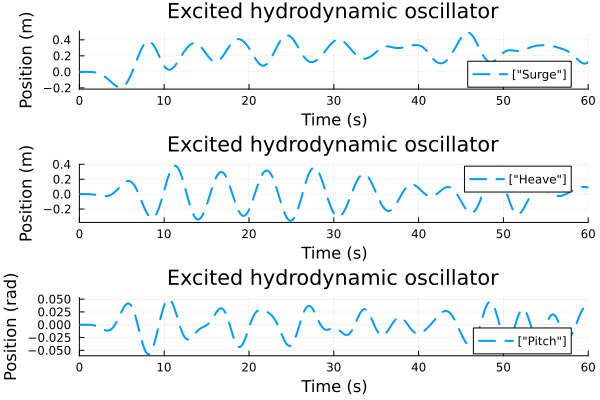

In [60]:
# Visualize response
p1 = Plots.plot(diffEqSol, idxs = [4], label = ["Surge"], title = "Excited hydrodynamic oscillator", xaxis="Time", yaxis = "Position", lw = 2, ls=:dash)
p2 = Plots.plot(diffEqSol, idxs = [5], label = ["Heave"], title = "Excited hydrodynamic oscillator", xaxis="Time", yaxis = "Position", lw = 2, ls=:dash)
p3 = Plots.plot(diffEqSol, idxs = [6], label = ["Pitch"], title = "Excited hydrodynamic oscillator", xaxis="Time", yaxis = "Position", lw = 2, ls=:dash)

Plots.plot(p1, p2, p3, layout=(3,1))

## Power performance
Finally, utilize the power or loss functions to calculate performance of the system and assess the gradient with respect to power.

ForwardDifference currently does not work with units. It will create zero / empty arrays of the input type (`Unitful Vector{Quantity{Float}}`) during the calculation which is too ambiguous to solve with.

Note that the differentiated functions must accept one and only one input (the quantity that the function output is differentiated against). If the energy or loss functions take both the AD input and the parameter set `p`, then they must be redefined as 1-argument anonymous functions:
```julia
gradient_fd = FD.gradient((cpto)->power_performance(cpto, p), pto_damping_ul)
gradient_loss_fd = FD.gradient((cpto)->power_loss(cpto, p), pto_damping_ul)
```

Note that there is no jacobian call because there is only a scalar output here (mean energy). There is no derivative call because the input (pto_damping) is not a scalar. For 1 DOF systems, keep pto_damping is a 1x1 vector to allow the use of gradient in both cases.

In [61]:
# Calculation of power and loss
function power_performance(pto_damping, p)
    (p2, dx₀, x₀, tspan, ts, dt, i_ramp) = p

    # Unwrap, edit and rewrap `p` to combine pto and radiation damping. 
    # p2[2] .= p2[2] .+ pto_damping # Don't do this - it overwrites the base p value, skewing iterative calls to power_performance
    (k, c, invMass, exCoeff, wave) = p2
    c = c .+ pto_damping
    p2 = (k, c, invMass, exCoeff, wave)
    
    diffEqSol = Hydrodynamics.hydrodynamicSolver(dx₀, x₀, ts, p2)

    # only absorb power in heave
    heave_ind = findall(x->x==3, Vector(dof))[1]
    heave_damping = pto_damping[heave_ind, heave_ind]
    heave_vel = diffEqSol[heave_ind,:]
    power = heave_vel .^ 2 .* heave_damping
    energy = sum(power[i_ramp:end]) * dt
    return energy
end

function power_performance(pto_damping)
    (p2, dx₀, x₀, tspan, ts, dt, i_ramp) = p

    # Unwrap, edit and rewrap `p` to combine pto and radiation damping. 
    # p2[2] .= p2[2] .+ pto_damping # Don't do this - it overwrites the base p value, skewing iterative calls to power_performance
    (k, c, invMass, exCoeff, wave) = p2
    c = c .+ pto_damping
    p2 = (k, c, invMass, exCoeff, wave)
    
    diffEqSol = Hydrodynamics.hydrodynamicSolver(dx₀, x₀, ts, p2)

    # only absorb power in heave
    heave_ind = findall(x->x==3, Vector(dof))[1]
    heave_damping = pto_damping[heave_ind, heave_ind]
    heave_vel = diffEqSol[heave_ind,:]
    power = heave_vel .^ 2 .* heave_damping
    energy = sum(power[i_ramp:end]) * dt
    return energy
end

function power_loss(pto_damping, p)
    # Note p /must/ be passed into power_performance. 
    # If not passed, power_performance uses the global 'p' instead of the 'p' redefined within this function call (counterintuitive yes) 
    - power_performance(pto_damping, p)
end

function power_loss(pto_damping)
    - power_performance(pto_damping)
end

power_loss (generic function with 2 methods)

In [62]:
### Calculate energy
# the power function works both with units and unitless
p = p_unitful
energy = power_performance(pto_damping)
loss = power_loss(pto_damping, p_unitful)

p = p_unitless
energy_ul = power_performance(pto_damping_ul)
loss_ul = power_loss(pto_damping_ul, p_unitless)
[energy loss; energy_ul loss_ul]

2×2 Matrix{Quantity{Float64}}:
 2.48671e5 kg m^2 s^-2  -2.48671e5 kg m^2 s^-2
 2.48663e5              -2.48663e5

In [63]:
### Calculate gradient of energy with respect to PTO damping
p = p_unitless

# PTO_damping is not a scalar input here so there is no derivative call.
# derivative_fd = FD.derivative(power_performance, pto_damping_ul[1])

# Use gradient for multiple dofs. Also works with a single dof if pto_damping is a 1x1 array
gradient_fd = FD.gradient(power_performance, pto_damping_ul)
gradient_loss_fd = FD.gradient(power_loss, pto_damping_ul)

3×3 Matrix{Float64}:
 -1.15549e-17   1.46998e-17   2.53991e-18
 -0.168009     -1.96365       0.0441474
  6.33842e-18  -1.40945e-17  -1.63567e-18